In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from pathlib import Path



In [7]:
# import funcs

%run ./utils.ipynb

In [5]:
source = '/cosma5/data/durham/dc-pick2/simulations/'
hyades_path = source + '/Hyades'
orbit_path = hyades_path + '/orbit.csv'

snapshots = [0, 60, 120, 180, 240]


In [4]:
orbit_df = pd.read_csv(orbit_path)

orbit_df['RG'] = np.sqrt(orbit_df['RGx']**2 + orbit_df['RGy']**2 + orbit_df['RGz']**2)

orbit_df

,T,RGx,RGy,RGz,VGx,VGy,VGz,JZ,ET,RG
0,0.000000,-1.760000,11.370000,0.110000,143.300000,2.400000,0.700000,-288070.060398,0.000000,11.505938
1,4.819376,-1.048345,11.341873,0.098368,145.309362,-13.864964,-5.384619,-288070.060398,-0.000944,11.390644
2,9.638751,-0.329208,11.232785,0.058226,146.319102,-30.454904,-10.634601,-288070.060398,0.794992,11.237759
3,14.458127,0.392300,11.041109,-0.001652,146.267898,-47.375080,-12.922355,-288070.060398,3.629713,11.048076
4,19.277502,1.110784,10.765321,-0.060729,145.078719,-64.572506,-10.268684,-288070.060398,8.714572,10.822646
...,...,...,...,...,...,...,...,...,...,...
126,607.241325,-0.731962,10.563830,0.049973,157.658347,-43.623777,11.270696,-288070.060398,109.405560,10.589276
127,612.060700,0.047089,10.304175,0.092150,158.249858,-61.814856,5.385190,-288070.060398,108.079036,10.304694
128,616.880076,0.825689,9.953776,0.100283,157.440477,-80.439213,-2.224171,-288070.060398,106.726712,9.988467
129,621.699452,1.596557,9.510521,0.070242,155.062343,-99.477372,-9.780530,-288070.060398,103.553842,9.643855


In [18]:
times = [0,100,200,300,400,500]

data, glob_df, Myr_per_Nbody = get_steps_at_times(hyades_path, times)


/tmp/ipykernel_3436756/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


In [40]:
xmin, xmax = -12, 12
ymin, ymax = -12, 12

#xmin, xmax = -27, 27
#ymin, ymax = -27, 27

zoom = 5

times = [0, 100, 200, 300, 400, 500]

# disk params
md = 1e11 #/ msc ! Msun -> Nbody units
rd = 5 #/ rsc ! kpc -> Nbody units
hz = .1 #/ rsc! kpc -> Nbody units

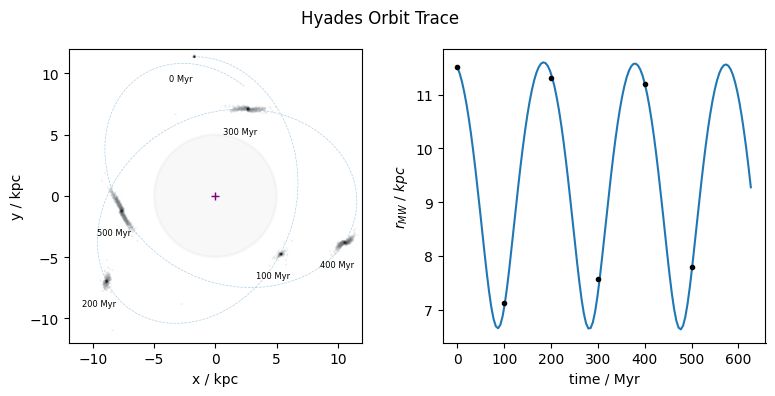

In [71]:


fig, ax = plt.subplots(1, 2, figsize=(8, 4))

snap_times = []
snap_idx = []

density = np.zeros((200, 200))

for t, stepdf in data.items():
    #t = stepdf.attrs['Time']
    
    idx = np.searchsorted(orbit_df['T'], t)
    galx = orbit_df['RGx'][idx]
    galy = orbit_df['RGy'][idx]

    zoomx = stepdf['X'] / 1000 * zoom
    zoomy = stepdf['Y'] / 1000 * zoom

    com_x = np.median(zoomx)
    com_y = np.median(zoomy)

    hist, _, _ = np.histogram2d(zoomx - com_x + galx, zoomy - com_y + galy,
                                bins=200, 
                                range=[[xmin, xmax],
                                       [ymin, ymax]])

    density += hist

    

    ax[0].text(galx - 2, galy - 2, f"{t:.0f} Myr", fontsize=6)
    
    ax[1].plot(t,orbit_df['RG'][idx], marker='.', color='black', zorder=10)


ax[0].imshow(np.log10(density.T+1), origin='lower', 
             extent=[xmin, xmax, ymin, ymax],
             cmap='gray_r', interpolation='spline36'
)

ax[0].plot(orbit_df['RGx'], orbit_df['RGy'], linestyle='dashed', alpha=0.35, color='tab:blue', linewidth=0.5)
ax[0].plot(0, 0, marker='+', color='purple', linestyle='')


ingal_disc = Circle((0,0), hz, color='gray', linewidth=2, label='inner galactic disk', alpha=0.07)
outgal_disc = Circle((0,0), rd, color='gray', linewidth=2, label='outer galactic disk', alpha=0.05)
ax[0].add_artist(ingal_disc)
ax[0].add_artist(outgal_disc)


ax[0].set_xlim([xmin, xmax])
ax[0].set_ylim([ymin, ymax])
ax[0].set_aspect('equal')
ax[0].set_xlabel("x / kpc")
ax[0].set_ylabel("y / kpc")

ax[1].plot(orbit_df['T'], orbit_df['RG'],  color='tab:blue')
ax[1].set_xlabel('time / Myr')
ax[1].set_ylabel(r'$r_{MW}\ /\ kpc$')

plt.suptitle('Hyades Orbit Trace')
plt.savefig('Images/HyadesOrbit.png')
plt.tight_layout()
plt.show()

In [20]:
glob_df.columns

Index(['TIME[NB}', 'TIME[Myr]', 'TCR[Myr]', 'DE', 'BE(3)', 'RSCALE[PC]',
       'RTIDE[PC]', 'RDENS[PC]', 'RC[PC]', 'RHOD[M*]', 'RHOM[M*]', 'MC[M*]',
       'CMAX', '<Cn>', 'Ir/R', 'RCM', 'VCM', 'AZ', 'EB/E', 'EM/E', 'VRMS', 'N',
       'NS', 'NPAIRS', 'NUPKS', 'NPKS', 'NMERGE', 'MULT', '<NB>', 'NC', 'NESC',
       'NSTEPI', 'NSTEPB', 'NSTEPR', 'NSTEPU', 'NSTEPT', 'NSTEPQ', 'NSTEPC',
       'NBLOCK', 'NBLCKR', 'NNPRED', 'NIRRF', 'NBCORR', 'NBFLUX', 'NBFULL',
       'NBVOID', 'NICONV', 'NLSMIN', 'NBSMIN', 'NBDIS', 'NBDIS2', 'NCMDER',
       'NFAST', 'NBFAST', 'NKSTRY', 'NKSREG', 'NKSHYP', 'NKSPER',
       'NKSMODNTTRY', 'NTRIP', 'NQUAD', 'NCHAIN', 'NMERG', 'NEWHI'],
      dtype='str')

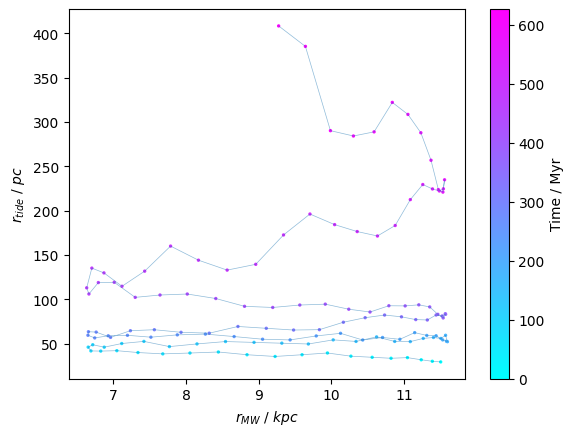

In [29]:
fig, ax = plt.subplots()
ax.plot(orbit_df['RG'] ,glob_df['RTIDE[PC]'], color='tab:blue', alpha=0.5, linewidth=0.5)
cb = ax.scatter(orbit_df['RG'] ,glob_df['RTIDE[PC]'], c=glob_df['TIME[Myr]'], cmap='cool', s=2)

plt.colorbar(cb, ax=ax, label='Time / Myr')

ax.set_xlabel(r'$r_{MW}\ /\ kpc$')
ax.set_ylabel(r'$r_{tide}\ /\ pc$')

plt.show()

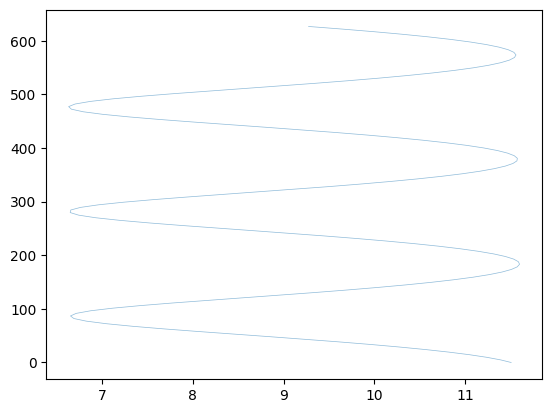

In [66]:
fig, ax = plt.subplots()
ax.plot(orbit_df['RG'] ,glob_df['TIME[Myr]'], color='tab:blue', alpha=0.5, linewidth=0.5)
#cb = ax.scatter(orbit_df['RG'] ,glob_df['RTIDE[PC]'], c=glob_df['TIME[Myr]'], cmap='cool', s=2)

#plt.colorbar(cb, ax=ax, label='Time / Myr')

#ax.set_xlabel(r'$r_{MW}\ /\ kpc$')
#ax.set_ylabel(r'$r_{tide}\ /\ pc$')

plt.show()

In [53]:
path = Path(source) / 'Concentration'

runs = get_runs(path)
orbit_dfs = {run:pd.read_csv(path / str(run) / 'orbit.csv') for run in runs}

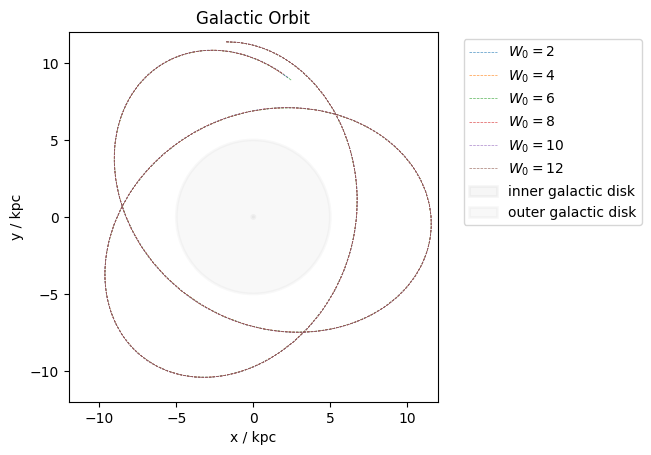

In [54]:
fig, ax = plt.subplots()
run_label='W_0'
xmin, xmax = -12, 12
ymin, ymax = -12, 12

for run,orbit_df in orbit_dfs.items():
    ax.plot(orbit_df['RGx'], orbit_df['RGy'], linestyle='dashed', alpha=0.8, linewidth=0.5,label=rf'${{{run_label}}}={run}$')


ingal_disc = Circle((0,0), hz, color='gray', linewidth=2, label='inner galactic disk', alpha=0.07)
outgal_disc = Circle((0,0), rd, color='gray', linewidth=2, label='outer galactic disk', alpha=0.05)
ax.add_artist(ingal_disc)
ax.add_artist(outgal_disc)


ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, ymax])
ax.set_aspect('equal')
ax.set_xlabel("x / kpc")
ax.set_ylabel("y / kpc")
ax.legend(bbox_to_anchor=(1.05, 1),)

ax.set_title("Galactic Orbit")

plt.show()

In [58]:
path = Path(source) / 'Mass'

runs = get_runs(path)
orbit_dfs = {run:pd.read_csv(path / str(run) / 'orbit.csv') for run in runs}

FileNotFoundError: [Errno 2] No such file or directory: '/cosma5/data/durham/dc-pick2/simulations/Mass/32500/orbit.csv'

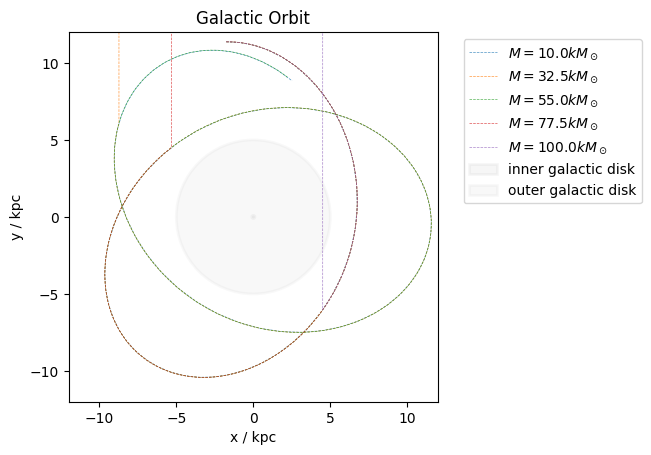

In [59]:
fig, ax = plt.subplots()
run_label='M'

for run,orbit_df in orbit_dfs.items():
    ax.plot(orbit_df['RGx'], orbit_df['RGy'], linestyle='dashed', alpha=0.8, linewidth=0.5,
            label=rf'${{{run_label}}}={run/1000}kM_\odot$')

ingal_disc = Circle((0,0), hz, color='gray', linewidth=2, label='inner galactic disk', alpha=0.07)
outgal_disc = Circle((0,0), rd, color='gray', linewidth=2, label='outer galactic disk', alpha=0.05)
ax.add_artist(ingal_disc)
ax.add_artist(outgal_disc)


ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, ymax])
ax.set_aspect('equal')
ax.set_xlabel("x / kpc")
ax.set_ylabel("y / kpc")
ax.legend(bbox_to_anchor=(1.05, 1),)

ax.set_title("Galactic Orbit")

plt.show()